<a href="https://colab.research.google.com/github/Manasi-spec/-DSBDA-MiniProject/blob/main/DSBDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "Month": np.tile(range(1, 13), 3),
    "Year": np.repeat([2022, 2023, 2024], 12),
    "Advertising_Spend": np.random.randint(1000, 5000, 36),
    "Discount": np.random.randint(5, 30, 36)
}

df = pd.DataFrame(data)
df["Sales"] = (
    8 * df["Advertising_Spend"]
    - 300 * df["Discount"]
    + 1500 * df["Month"]
    + np.random.randint(0, 3000, 36)
)

df.to_csv("sales_data.csv", index=False)

df.head()

,Month,Year,Advertising_Spend,Discount,Sales
0,1,2022,4174,16,32047
1,2,2022,4507,29,31941
2,3,2022,1860,21,14101
3,4,2022,2294,14,22765
4,5,2022,2130,20,19669


In [2]:
import pandas as pd

df = pd.read_csv("sales_data.csv")

print(df.head())
print(df.info())
print(df.describe())

   Month  Year  Advertising_Spend  Discount  Sales
0      1  2022               4174        16  32047
1      2  2022               4507        29  31941
2      3  2022               1860        21  14101
3      4  2022               2294        14  22765
4      5  2022               2130        20  19669
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Month              36 non-null     int64
 1   Year               36 non-null     int64
 2   Advertising_Spend  36 non-null     int64
 3   Discount           36 non-null     int64
 4   Sales              36 non-null     int64
dtypes: int64(5)
memory usage: 1.5 KB
None
          Month         Year  Advertising_Spend   Discount         Sales
count  36.00000    36.000000          36.000000  36.000000     36.000000
mean    6.50000  2023.000000        2975.972222  17.944444  29542.333333
std     

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Month              36 non-null     int64
 1   Year               36 non-null     int64
 2   Advertising_Spend  36 non-null     int64
 3   Discount           36 non-null     int64
 4   Sales              36 non-null     int64
dtypes: int64(5)
memory usage: 1.5 KB
None
          Month         Year  Advertising_Spend   Discount         Sales
count  36.00000    36.000000          36.000000  36.000000     36.000000
mean    6.50000  2023.000000        2975.972222  17.944444  29542.333333
std     3.50102     0.828079        1147.888882   6.654513   9602.249760
min     1.00000  2022.000000        1021.000000   6.000000  12021.000000
25%     3.75000  2022.000000        2121.250000  12.750000  21179.500000
50%     6.50000  2023.000000        2910.000000  19.000000  30220.000000
75%     9.25000  2024.

In [4]:
print(df.isnull().sum())

Month                0
Year                 0
Advertising_Spend    0
Discount             0
Sales                0
dtype: int64


In [23]:
df=df.drop_duplicates()

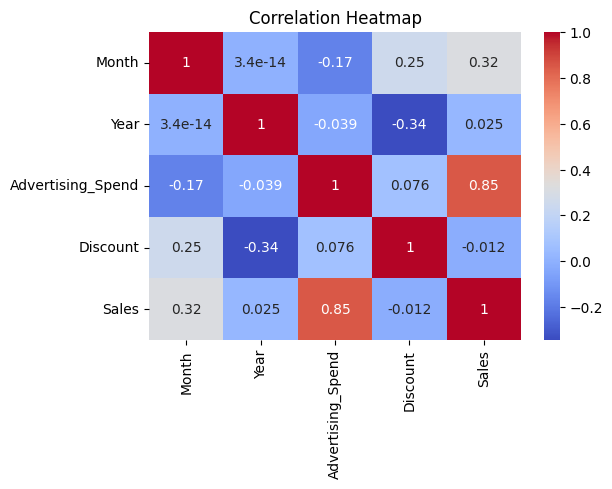

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
X = df[["Advertising_Spend", "Discount", "Month", "Year"]]
y = df["Sales"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 556293.1565643483
RMSE: 745.8506261741343
R2 Score: 0.993369396933342


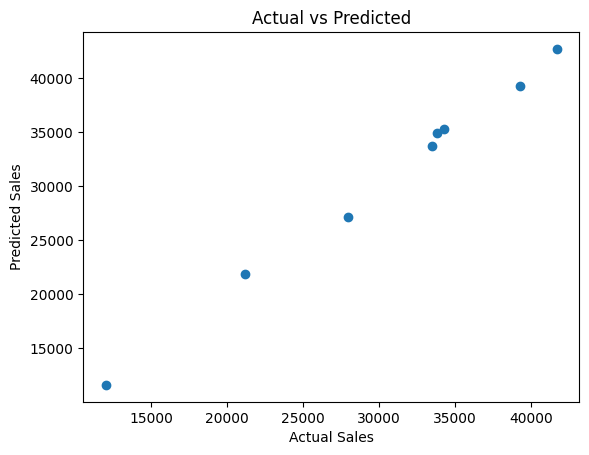

In [29]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()


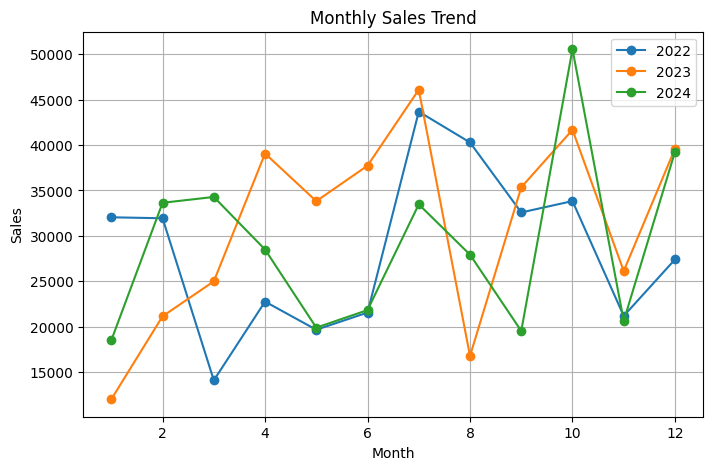

In [30]:
plt.figure(figsize=(8,5))

for year in df["Year"].unique():
    data = df[df["Year"] == year]
    plt.plot(data["Month"], data["Sales"], marker='o', label=year)

plt.legend()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

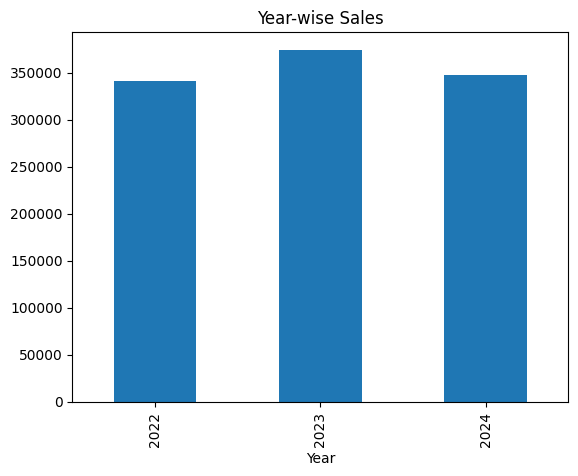

In [31]:
df.groupby("Year")["Sales"].sum().plot(kind="bar")
plt.title("Year-wise Sales")
plt.show()

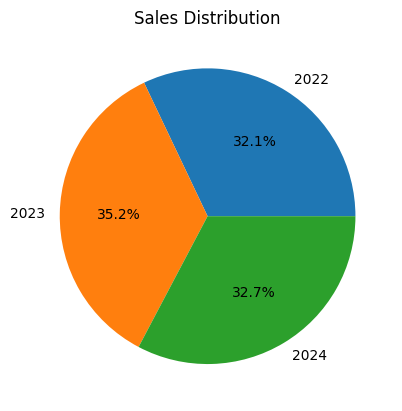

In [32]:
df.groupby("Year")["Sales"].sum().plot(
    kind="pie", autopct="%1.1f%%"
)
plt.title("Sales Distribution")
plt.ylabel("")
plt.show()

In [47]:
future_data = pd.DataFrame({
    "Advertising_Spend": [5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000,7200],
    "Discount": [10,12,8,15,10,5,12,10,8,15,10,5],
    "Month": list(range(1,13)),
    "Year": [2025]*12

})

In [34]:
future_predictions = model.predict(future_data)
future_data["Predicted_Sales"] = future_predictions

print(future_data)

    Advertising_Spend  Discount  Month  Year  Predicted_Sales
0                5000        10      1  2025     40291.856990
1                5200        12      2  2025     42756.004140
2                5400         8      3  2025     47141.012561
3                5600        15      4  2025     48004.441985
4                5800        10      5  2025     52709.593952
5                6000         5      6  2025     57414.745919
6                6200        12      7  2025     58278.175343
7                6400        10      8  2025     62022.896674
8                6600         8      9  2025     65767.618005
9                6800        15     10  2025     66631.047429
10               7000        10     11  2025     71336.199395
11               7200         5     12  2025     76041.351362


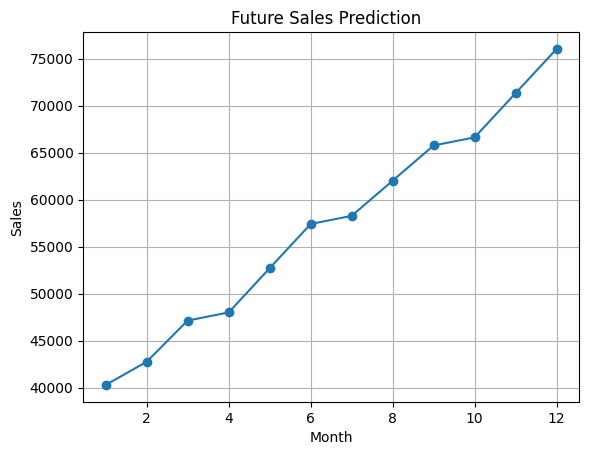

In [40]:
plt.plot(future_data["Month"], future_data["Predicted_Sales"], marker='o')
plt.title("Future Sales Prediction  ")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [36]:
from sklearn.tree import DecisionTreeRegressor

# Create model
dt_model = DecisionTreeRegressor(random_state=42)

# Train
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict
dt_pred = dt_model.predict(X_test)

# Evaluate
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results:")
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Results:
MSE: 35368929.25
RMSE: 5947.178259477347
R2 Score: 0.578428517442436


In [38]:
print("Linear Regression R2:", r2)
print("Decision Tree R2:", dt_r2)


Linear Regression R2: 0.993369396933342
Decision Tree R2: 0.578428517442436


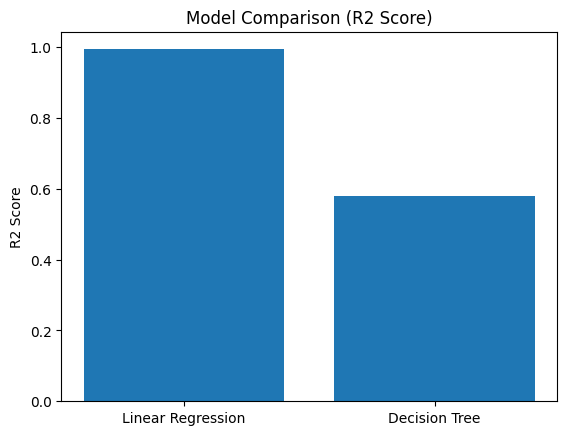

In [39]:
models = ["Linear Regression", "Decision Tree"]
scores = [r2, dt_r2]

plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()


In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [49]:
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Linear Regression Metrics
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

# Decision Tree Metrics
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

# Print Results
print("🔹 Linear Regression")
print("R2 Score:", lr_r2)
print("RMSE:", lr_rmse)

print("\n🔹 Decision Tree")
print("R2 Score:", dt_r2)
print("RMSE:", dt_rmse)

🔹 Linear Regression
R2 Score: 0.993369396933342
RMSE: 745.8506261741343

🔹 Decision Tree
R2 Score: 0.578428517442436
RMSE: 5947.178259477347


In [51]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "R2 Score": [lr_r2, dt_r2],
    "RMSE": [lr_rmse, dt_rmse]
})

print(comparison)

               Model  R2 Score         RMSE
0  Linear Regression  0.993369   745.850626
1      Decision Tree  0.578429  5947.178259


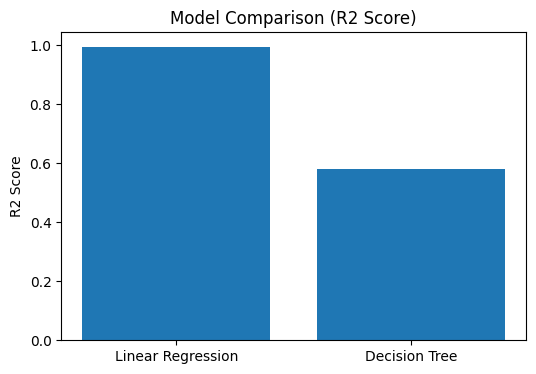

In [52]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree"]
r2_scores = [lr_r2, dt_r2]

plt.figure(figsize=(6,4))
plt.bar(models, r2_scores)

plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")

plt.show()

(0.0, 1.0)

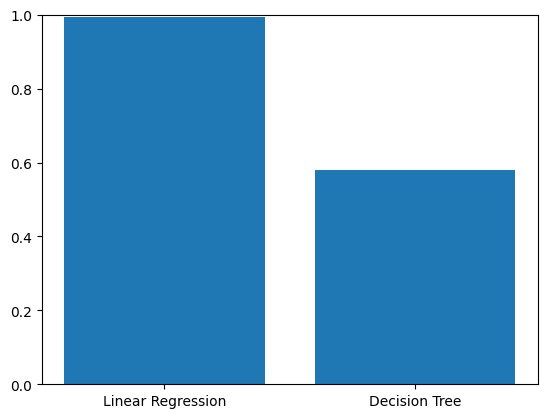

In [53]:
plt.bar(models, r2_scores)
plt.ylim(0,1)